# Assignment 3 step 3: combined heatmap (one sidebar per clustering method + diagnosis)

Heatmap of the 5,000 most variable genes across the 89 AnCg libraries, z scored per gene, with row (gene)
and column (library) dendrograms from Ward linkage, so the library dendrogram is the same tree as the
hierarchical clustering in `Assignment3_daniel.ipynb`.

Each method contributes one set of labels through a file in `results/`:

| method | file | column used |
|---|---|---|
| Hierarchical, Ward (Daniel) | `results/a3_labels_hclust.tsv` | `g5000_k2` |
| K-means (Vicky) | `results/a3_labels_kmeans.tsv` | `g5000_k2` |
| PAM (Alice) | `results/a3_labels_pam.tsv` | `g5000_k2` |

Format: tab separated, index `refinebio_title` (library name), one column per clustering version.
If the k-means file is missing, the cell below reproduces Vicky's exact call from `Assignment3.ipynb`
(KMeans with k = 2, random_state = 0, n_init = "auto", unscaled log2 values of the same 5,000 genes).
If the PAM file is missing, that sidebar is skipped until Alice adds it. Rerun this notebook after she does.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from sklearn.cluster import KMeans

DX_ORDER = ["control", "major depression", "bipolar disorder", "schizophrenia"]
DX_NAME = {"control": "Control", "major depression": "Depression",
           "bipolar disorder": "Bipolar", "schizophrenia": "Schizophrenia"}
DX_COLOR = {"control": "#9a9893", "major depression": "#1baf7a",
            "bipolar disorder": "#2a78d6", "schizophrenia": "#eb6834"}
# clusters are renamed C1, C2, ... from largest to smallest so the same color means the same kind of cluster
# in every method's sidebar (C1 = the big mixed cluster)
CLUSTER_COLORS = ["#d9d7d0", "#4a3aa7", "#e87ba4", "#008300", "#e34948", "#eda100"]

## Load the same 89 libraries and 5,000 genes as the clustering notebooks

In [2]:
expr_lib = pd.read_csv("data/expr_by_library.tsv.gz", sep="\t", index_col=0)
meta_lib = pd.read_csv("data/meta_by_library.tsv", sep="\t", index_col=0)
meta_a = meta_lib[meta_lib.region == "ancg"].copy()
log_expr = np.log2(expr_lib[meta_a.index] + 1)
log_expr = log_expr[log_expr.median(axis=1) > 0]
top = log_expr.var(axis=1).sort_values(ascending=False).index[:5000]
X = log_expr.loc[top].T                      # libraries x genes, log2 scale
Z = (X - X.mean()) / X.std()                 # z score per gene
print(Z.shape)

(89, 5000)


## Collect one set of cluster labels per method

In [3]:
METHODS = {
    "Hierarchical (Ward)": ("results/a3_labels_hclust.tsv", "g5000_k2"),
    "K-means": ("results/a3_labels_kmeans.tsv", "g5000_k2"),
    "PAM": ("results/a3_labels_pam.tsv", "g5000_k2"),
}

ann = pd.DataFrame(index=meta_a.index)
for name, (path, col) in METHODS.items():
    if os.path.exists(path):
        ann[name] = pd.read_csv(path, sep="\t", index_col=0).loc[meta_a.index, col]
        print(f"{name}: loaded {path} [{col}]")
    elif name == "K-means":
        ann[name] = KMeans(n_clusters=2, random_state=0, n_init="auto").fit_predict(X)
        print(f"{name}: {path} not found, reproduced Vicky's k-means call")
    else:
        print(f"{name}: {path} not found, sidebar skipped")

# rename clusters by size: C1 = largest
for name in ann.columns:
    order = ann[name].value_counts().index
    ann[name] = ann[name].map({c: f"C{i + 1}" for i, c in enumerate(order)})
ann["Diagnosis"] = meta_a.dx

for name in ann.columns[:-1]:
    print(f"\n{name}")
    print(pd.crosstab(ann[name], ann["Diagnosis"]).reindex(columns=DX_ORDER).rename(columns=DX_NAME).to_string())

Hierarchical (Ward): loaded results/a3_labels_hclust.tsv [g5000_k2]
K-means: results/a3_labels_kmeans.tsv not found, reproduced Vicky's k-means call
PAM: results/a3_labels_pam.tsv not found, sidebar skipped

Hierarchical (Ward)
Diagnosis            Control  Depression  Bipolar  Schizophrenia
Hierarchical (Ward)                                             
C1                        22          22       14             16
C2                         0           0        8              7

K-means
Diagnosis  Control  Depression  Bipolar  Schizophrenia
K-means                                               
C1              22          22       15             16
C2               0           0        7              7


## Heatmap

/usr/local/lib/python3.13/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


/usr/local/lib/python3.13/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


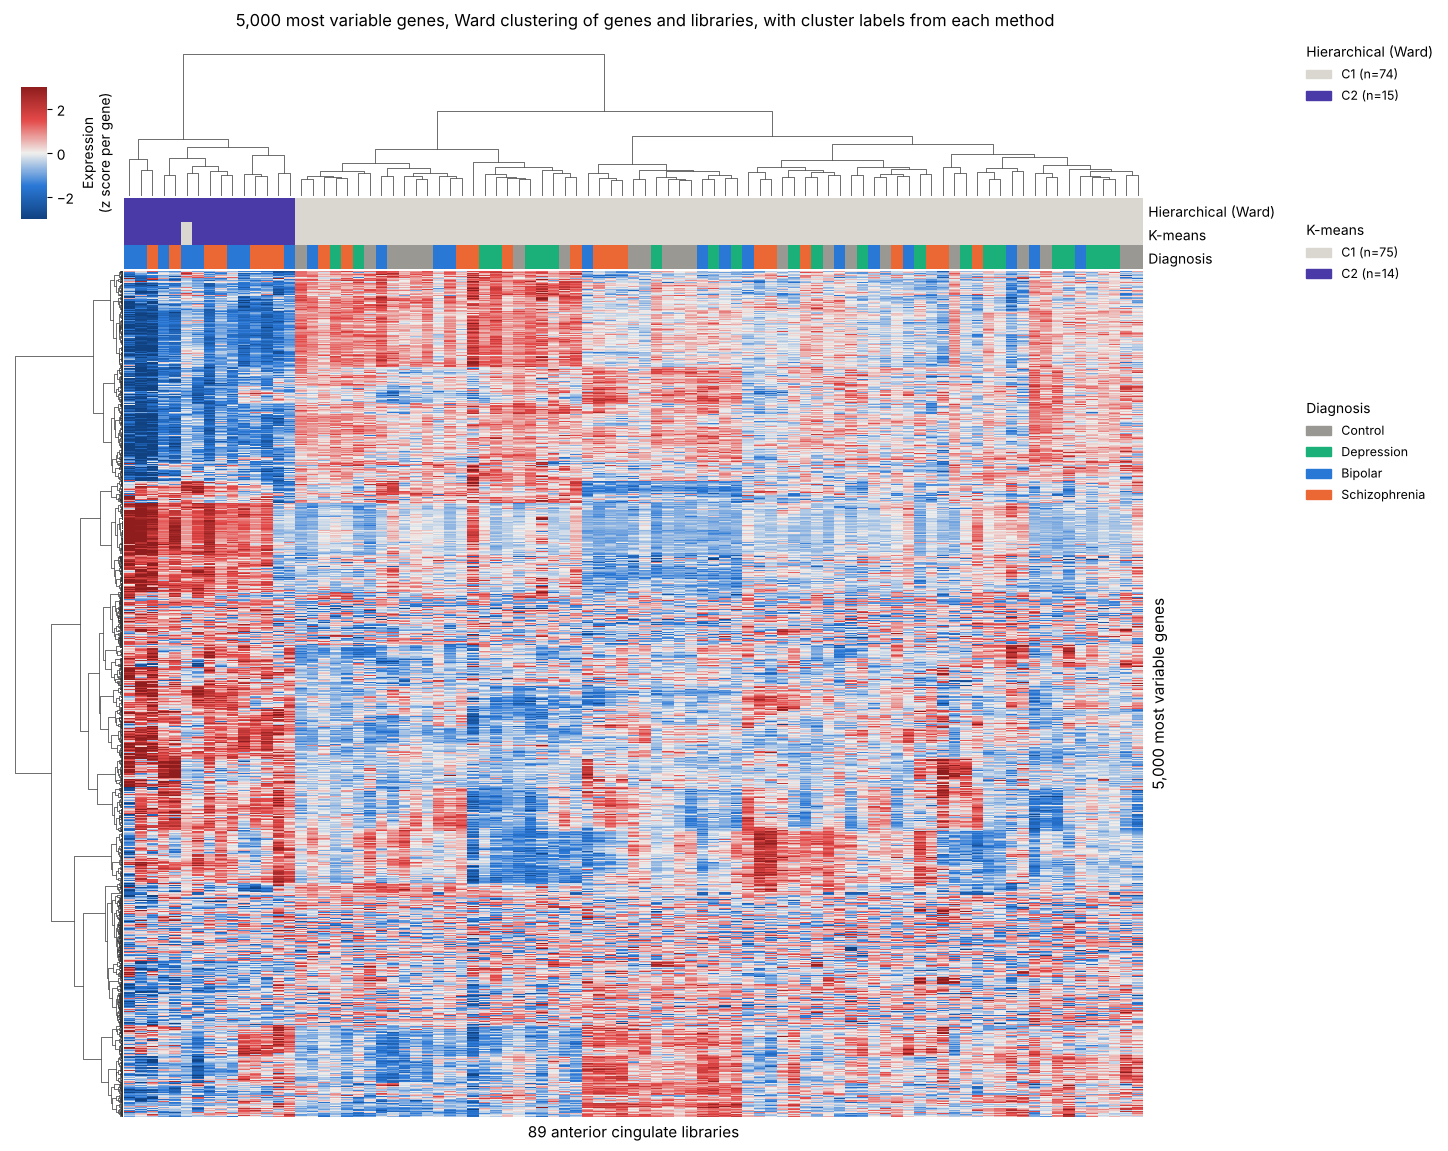

In [4]:
col_colors = pd.DataFrame(index=ann.index)
legend_sets = {}
for name in ann.columns:
    if name == "Diagnosis":
        cmap = {d: DX_COLOR[d] for d in DX_ORDER}
        legend_sets[name] = [(DX_NAME[d], DX_COLOR[d]) for d in DX_ORDER]
    else:
        levels = sorted(ann[name].unique(), key=lambda s: int(s[1:]))
        cmap = dict(zip(levels, CLUSTER_COLORS))
        sizes = ann[name].value_counts()
        legend_sets[name] = [(f"{c} (n={sizes[c]})", cmap[c]) for c in levels]
    col_colors[name] = ann[name].map(cmap)

diverging = LinearSegmentedColormap.from_list("bwr", ["#104281", "#2a78d6", "#f0efec", "#e34948", "#8f1d1d"])

g = sns.clustermap(
    Z.T.clip(-3, 3),                 # genes x libraries, z scores clipped at +/- 3 for color range
    method="ward", metric="euclidean",
    row_cluster=True, col_cluster=True,
    col_colors=col_colors,
    cmap=diverging, center=0, vmin=-3, vmax=3,
    xticklabels=False, yticklabels=False,
    figsize=(13, 11), dendrogram_ratio=(0.1, 0.14), colors_ratio=0.022,
    cbar_pos=(0.02, 0.83, 0.02, 0.12),
    cbar_kws={"label": "Expression\n(z score per gene)"},
)
g.ax_heatmap.set_xlabel("89 anterior cingulate libraries", fontsize=11)
g.ax_heatmap.set_ylabel("5,000 most variable genes", fontsize=11)
g.ax_col_colors.set_yticks(np.arange(col_colors.shape[1]) + 0.5)
g.ax_col_colors.set_yticklabels(col_colors.columns, fontsize=10)
g.ax_col_colors.yaxis.tick_right()
g.ax_col_colors.tick_params(length=0)

y = 1.0
for name, items in legend_sets.items():
    leg = g.fig.legend(handles=[Patch(color=c, label=l) for l, c in items], title=name,
                       loc="upper left", bbox_to_anchor=(1.0, y), frameon=False, fontsize=9,
                       title_fontsize=10, alignment="left")
    y -= 0.045 * (len(items) + 1.6)
g.fig.suptitle("5,000 most variable genes, Ward clustering of genes and libraries, with cluster labels from each method",
               x=0.5, y=1.02, fontsize=12)
g.savefig("plots/a3_heatmap_all_methods.png", dpi=200, bbox_inches="tight")
plt.show()